In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("../OnlineRetail.xlsx")

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['Revenue'] = df['Quantity'] * df['Price']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      417534 non-null  object        
 8   Revenue      417534 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.9+ MB


In [12]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,417534.000000,417534,417534.000000,417534.000000,417534.000000
mean,12.758815,2010-07-01 01:12:19.787609856,3.887547,15360.645478,19.994081
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000,-25111.090000
25%,2.000000,2010-03-26 11:26:00,1.250000,13983.000000,4.250000
50%,4.000000,2010-07-08 19:12:00,1.950000,15311.000000,11.250000
75%,12.000000,2010-10-14 14:08:00,3.750000,16799.000000,19.350000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,15818.400000
std,101.220424,NaN,71.131797,1680.811316,99.915863


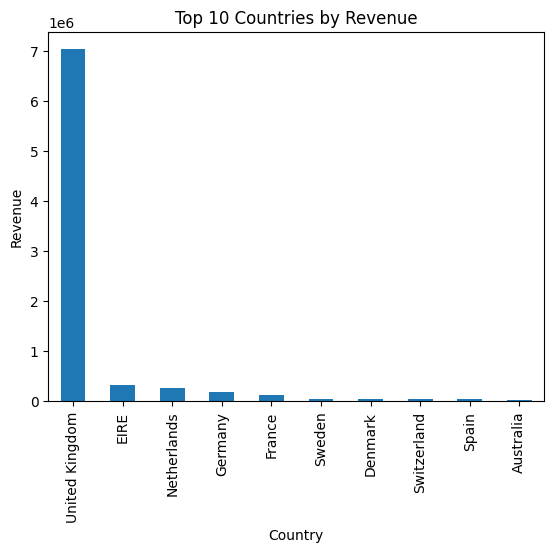

In [13]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.show()

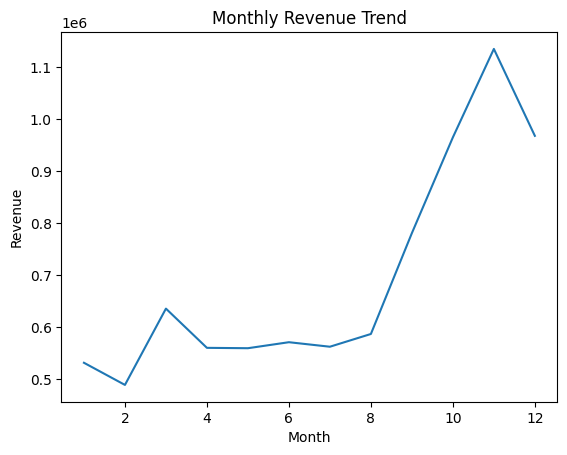

In [14]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.month)['Revenue'].sum()

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

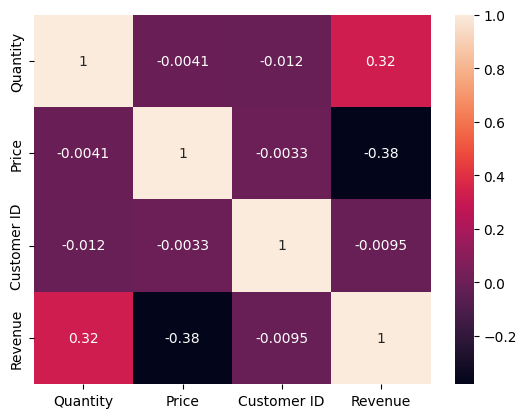

In [15]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)

plt.show()

In [16]:
from sklearn.cluster import KMeans

In [18]:
customer = df.groupby('Customer ID').agg({
    'Revenue':'sum',
    'Quantity':'sum'
}).reset_index()

In [19]:
kmeans = KMeans(n_clusters=3)

customer['Cluster'] = kmeans.fit_predict(customer[['Revenue','Quantity']])

C:\Users\deepi\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\deepi\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\deepi\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Program Files\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python310\lib\subprocess.py", line 971, in __init__
    s

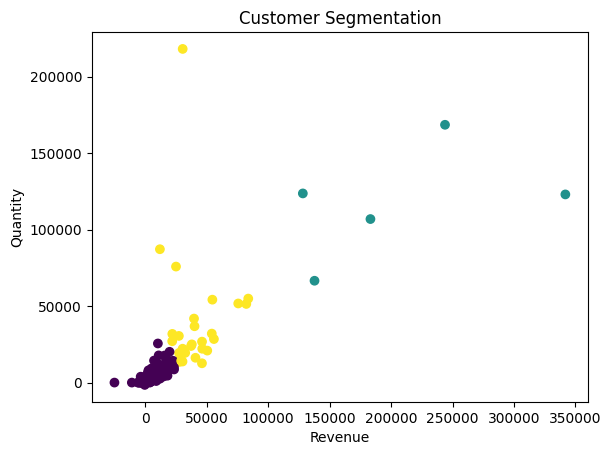

In [20]:
plt.scatter(customer['Revenue'], customer['Quantity'], c=customer['Cluster'])

plt.title("Customer Segmentation")

plt.xlabel("Revenue")

plt.ylabel("Quantity")

plt.show()

In [21]:
from prophet import Prophet

C:\Users\deepi\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [22]:
forecast_df = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()

In [23]:
forecast_df.columns = ['ds', 'y']

In [24]:
forecast_df.head()

,ds,y
0,2009-12-01,42708.22
1,2009-12-02,52578.19
2,2009-12-03,61534.22
3,2009-12-04,33686.86
4,2009-12-05,9803.05


In [25]:
model = Prophet()

In [26]:
model.fit(forecast_df)

15:47:38 - cmdstanpy - INFO - Chain [1] start processing
15:47:40 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
future = model.make_future_dataframe(periods=30)

In [28]:
forecast = model.predict(future)

In [29]:
forecast[['ds','yhat']].tail()

,ds,yhat
332,2011-01-04,48573.181799
333,2011-01-05,47302.192108
334,2011-01-06,52365.657951
335,2011-01-07,43406.488846
336,2011-01-08,31530.887458


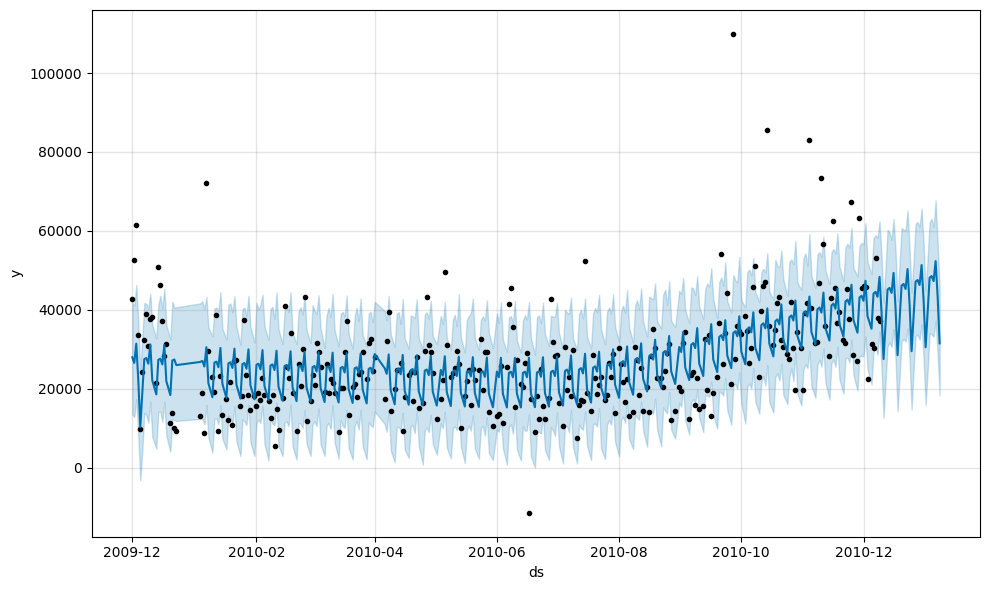

In [30]:
model.plot(forecast)
plt.show()

In [31]:
customer['Churn'] = customer['Quantity'].apply(lambda x: 1 if x < 100 else 0)

In [32]:
from sklearn.model_selection import train_test_split

X = customer[['Revenue','Quantity']]

y = customer['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from xgboost import XGBClassifier

In [34]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [35]:
predictions = xgb_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


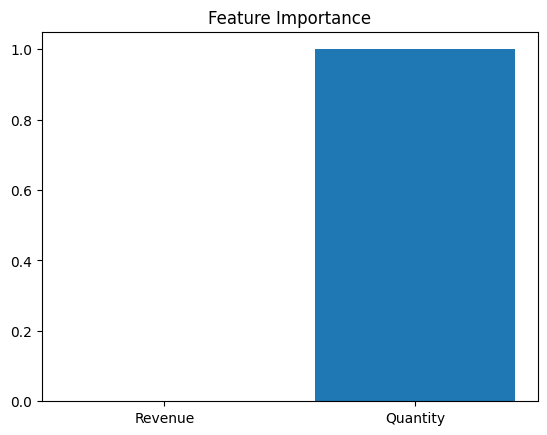

In [37]:
importance = xgb_model.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.title("Feature Importance")

plt.show()

In [38]:
low_products = df.groupby('Description')['Revenue'].sum().sort_values().head(10)

print(low_products)

Description
Manual                                -126767.77
Discount                                -7694.03
Adjustment by Peter on 24/05/2010 1      -731.05
SILVER CHERRY LIGHTS                     -618.10
WHITE CHERRY LIGHTS                      -556.05
TREE OF NOAH FESTIVE SCENTED CANDLE      -161.30
BLACK CHERRY LIGHTS                       -75.00
VINTAGE BLUE VACUUM FLASK 0.5L            -67.50
CREAM SWEETHEART DOUBLE SHELF             -50.85
WHITE ORCHID FLOWER LIGHTS                -45.30
Name: Revenue, dtype: float64
